## ِArabic VQA System



In [ ]:
# install requirements
# To use AraGPT 2 From M github *******************
!pip install transformers
!pip install farasapy
!pip install pyarabic
!pip --q install arabert
#************************************

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 1.6 MB/s eta 0:00:00


In [ ]:
# To use AraGPT 2 From M github ************************************
!git clone https://github.com/aub-mind/arabert.git
#************************************

Cloning into 'arabert'...
remote: Enumerating objects: 600, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 600 (delta 38), reused 45 (delta 30), pack-reused 535
Receiving objects: 100% (600/600), 9.14 MiB | 22.24 MiB/s, done.
Resolving deltas: 100% (339/339), done.


In [ ]:
import torch

# For image processing
from PIL import Image
# If we use the part that fetches the image from a URL
import requests
# For displaying the image in Jupyter notebooks or similar environments
from IPython.display import display
# For mounting with the google drive
from google.colab import drive


### Load the Arabic LLM (AraGPT-2)

In [ ]:
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, AutoModelForSeq2SeqLM

from transformers import GPT2TokenizerFast, pipeline
# for base and medium
from transformers import GPT2LMHeadModel
# for large and mega
# pip install arabert, then from arabert.preprocess import ArabertPreprocessor
from arabert.preprocess import ArabertPreprocessor

# The function modified to follow Mariam code (GPT2LMHeadModel, GPT2TokenizerFast)
def load_model(model_selection):
    model = GPT2LMHeadModel.from_pretrained(model_selection)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_selection, use_fast=False)
    # From M github ************
    generation_pipel = pipeline("text-generation",model=model,tokenizer=tokenizer)
    # ***************************
    return model,tokenizer,generation_pipel

# Choose LLM to use
# weights for AraGPT2(Base)-135M/AraGPT2(medium)-370M/AraGPT2(large)-792M/AraGPT2(mega)-1.46B
print("Loading Large Language Model (LLM)...")
MODEL_NAME='aubmindlab/aragpt2-base'
# MODEL_NAME='aubmindlab/aragpt2-medium' # ~?G (FP16)
# MODEL_NAME='aubmindlab/aragpt2-large' # ~?G (FP16)
# MODEL_NAME='aubmindlab/aragpt2-mega' # ~?G (FP16)
# From M github ************
arabert_prep = ArabertPreprocessor(model_name=MODEL_NAME)
# ***************************

llm_model, tokenizer, generation_pipeline = load_model(MODEL_NAME)  # ~?G ToDo: check the required size of the model's weights

# From M github ************
#generation_pipeline = pipeline("text-generation",model=model,tokenizer=tokenizer)
# ***************************

Loading Large Language Model (LLM)...


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.52M [00:00<?, ?B/s]

Load an example image and question

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ما هو اسم الأداة التي تستخدم لأكل هذا الطعام؟


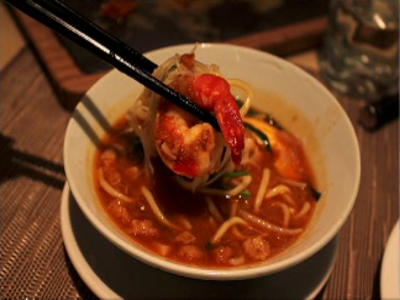

In [ ]:
# img_url = 'https://....../example.png'
# raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

drive.mount('/content/drive')
raw_image = Image.open("/content/drive/MyDrive/Colab Notebooks/E2.png").convert("RGB")
question = "ما هو اسم الأداة التي تستخدم لأكل هذا الطعام؟"
print(question)
display(raw_image.resize((400, 300)))

In [ ]:
# setup device to use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Loading Arabic Image Captioning Model 1 (BiT) from GitHub

In [ ]:
# 1. Clone the GitHub Repository
!git clone https://github.com/jontooy/Arabic-Image-Captioning-using-Transformers.git
# 2. Install Dependencies (No requiremrnts.txt file)
# 3. Download Pre-trained Weights
# 4. Use the Model

Cloning into 'Arabic-Image-Captioning-using-Transformers'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 22 (delta 3), reused 0 (delta 0), pack-reused 0
Receiving objects: 100% (22/22), 50.79 KiB | 1.37 MiB/s, done.
Resolving deltas: 100% (3/3), done.


### Loading Arabic Image Captioning Model 2 (Violet)

### Image Captioning module


1.   Generate the captions using the selected Arabic Image Captioning models
2.   Filter the captions
3.   Save the captions **bold text**

### N Caption Selection and Context Building

This section will be used by the Prompt builder to get the required Context including one of the following:


1.   Empty String as a context.
2.   N captions generated from BiT.
3.   N captions generated from Violet.
4.   N captions generated from both BiT and Violet.

The selection of the N captions in cases 2, 3, and 4 will be conducted using subsection to offer the following selection:


1.   N randomly selected captions.
2.   N captions highly similar with the question.
3.   N captions that have low similarity score with the question.
3.   N captions that have low similarity score with the question and the answer.


### Prompt Construction
Prepare the prompts for LLM

In [ ]:
#Prompts = prompts_construction(samples)
caption1 = "وعاء من الحساء مع الجمبري فوقه"
caption2 = "وعاء من الحساء مع الخضار واللحوم"
caption3 = "وعاء حساء نودلز وعيدان تناول الطعام فيه"

prompt= "أجب عن السؤال من السياق التالي."+ " السياق: "+caption1+"، "+caption2+"، "+caption3+"."+" السؤال: "+question
prompt

'أجب عن السؤال من السياق التالي. السياق: وعاء من الحساء مع الجمبري فوقه، وعاء من الحساء مع الخضار واللحوم، وعاء حساء نودلز وعيدان تناول الطعام فيه. السؤال: ما هو اسم الأداة التي تستخدم لأكل هذا الطعام؟'

### Predict the answer using AraGPT2 model

In [ ]:
# From M github *****************
input_ids = tokenizer.encode(prompt, return_tensors = 'pt')
input_ids
tokenizer.decode(input_ids[0])
def generate_answer(prompt):
  prompt_clean = arabert_prep.preprocess(prompt)
  result = generation_pipeline(prompt_clean,
                                pad_token_id=tokenizer.eos_token_id,
                                num_beams=3,
                                max_length=100,
                                top_p=0.9,
                                repetition_penalty = 1.0,
                                no_repeat_ngram_size = 3)[0]['generated_text']
  return result
#******************************

#text_clean = arabert_prep.preprocess(text)

#model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
#tokenizer = GPT2TokenizerFast.from_pretrained(MODEL_NAME)
#generation_pipeline = pipeline("text-generation",model=model,tokenizer=tokenizer)

#feel free to try different decoding settings
#generation_pipeline(text,
#    pad_token_id=tokenizer.eos_token_id,
#    num_beams=10,
#    max_length=200,
#    top_p=0.9,
#    repetition_penalty = 3.0,
#    no_repeat_ngram_size = 3)[0]['generated_text']

In [ ]:
generate_answer(prompt)

'أجب عن السؤال من السياق التالي . السياق : وعاء من الحساء مع الجمبري فوقه ، وعاء من الحساء مع الخضار واللحوم ، وعاء حساء نودلز وعيدان تناول الطعام فيه . السؤال : ما هو اسم الأداة التي تستخدم لأكل هذا الطعام ؟ الجواب : هو وعاء من اللحم أو الدجاج أو السمك أو الدجاج ، أو ما شابه ذلك من المأكولات. الجواب : نعم ، هو وعاء...'

### Save results